# Notebook 01 — Data Exploration

This notebook explores the Wikipedia edit history data parsed from Wikimedia XML dumps into Parquet format.
We examine:
- Dataset size and schema
- Edit volume per wiki
- Editor activity distributions
- Temporal patterns (edits over time)
- Bot vs human edit ratio
- Storage comparison: XML vs Parquet

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os, glob

plt.style.use('seaborn-v0_8-darkgrid')
RESULTS = '../data/results'
PARQUET = '../data/parquet'
DUMPS   = '../data/dumps'
os.makedirs(RESULTS, exist_ok=True)

## 1. Load Parquet Data

In [2]:
wikis = ['enwiki', 'dewiki', 'frwiki', 'jawiki', 'eswiki']
dfs = {}
for wiki in wikis:
    path = os.path.join(PARQUET, f'{wiki}.parquet')
    if os.path.exists(path):
        dfs[wiki] = pd.read_parquet(path)
        print(f'{wiki}: {len(dfs[wiki]):,} revisions, {dfs[wiki]["contributor_id"].nunique():,} distinct editors')

df_all = pd.concat(dfs.values(), ignore_index=True)
print(f'\nTotal: {len(df_all):,} revisions across {len(dfs)} wikis')
df_all.head()

enwiki: 26,165,118 revisions, 1,402,943 distinct editors
dewiki: 26,108,033 revisions, 456,642 distinct editors
frwiki: 24,847,986 revisions, 466,044 distinct editors
jawiki: 9,921,647 revisions, 246,557 distinct editors
eswiki: 14,772,589 revisions, 470,050 distinct editors

Total: 101,815,373 revisions across 5 wikis


,wiki,page_id,page_title,page_namespace,revision_id,parent_id,timestamp,contributor_id,contributor_name,is_anonymous,comment,text_bytes
0,enwiki,10,AccessibleComputing,0,233192,0,2001-01-21T02:12:21Z,99,RoseParks,False,*,124
1,enwiki,10,AccessibleComputing,0,862220,233192,2002-02-25T15:43:11Z,1226483,Conversion script,False,Automated conversion,35
2,enwiki,10,AccessibleComputing,0,15898945,862220,2003-04-25T22:18:38Z,7543,Ams80,False,Fixing redirect,34
3,enwiki,10,AccessibleComputing,0,56681914,15898945,2006-06-03T16:55:41Z,516514,Nzd,False,fix double redirect,36
4,enwiki,10,AccessibleComputing,0,74466685,56681914,2006-09-08T04:16:04Z,750223,Rory096,False,cat rd,57


## 2. Edit Volume Per Wiki

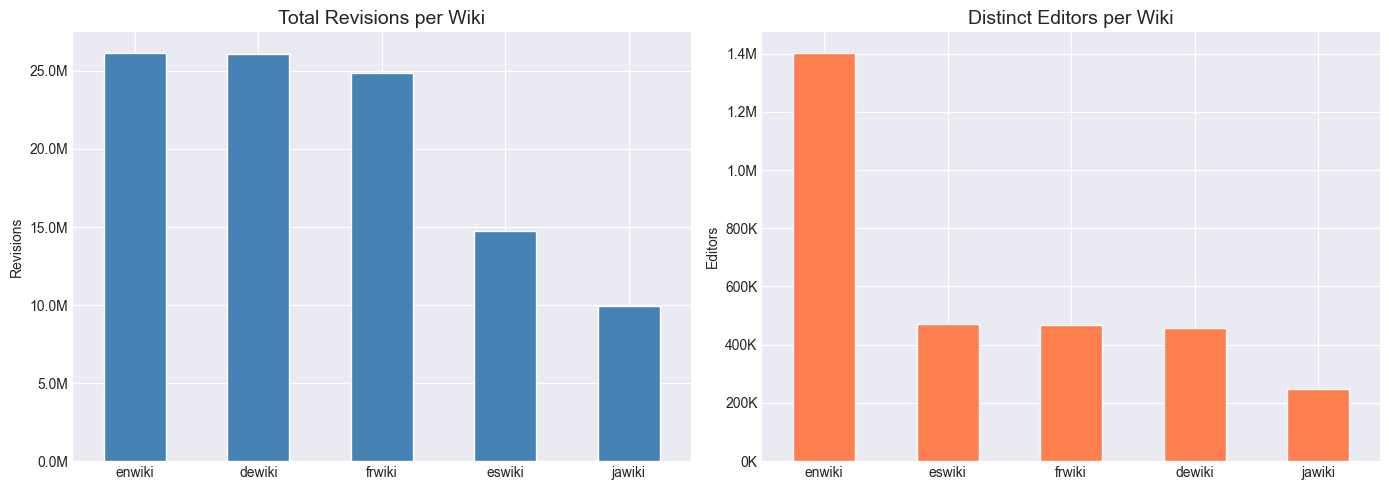

wiki
enwiki    26165118
dewiki    26108033
frwiki    24847986
eswiki    14772589
jawiki     9921647
dtype: int64


In [3]:
edit_counts = df_all.groupby('wiki').size().sort_values(ascending=False)
editor_counts = df_all.groupby('wiki')['contributor_id'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edit_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Revisions per Wiki', fontsize=14)
axes[0].set_ylabel('Revisions')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=0)

editor_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distinct Editors per Wiki', fontsize=14)
axes[1].set_ylabel('Editors')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, '01_edit_volume.png'), dpi=150)
plt.show()
print(edit_counts)

## 3. Editor Activity Distribution (Power Law)

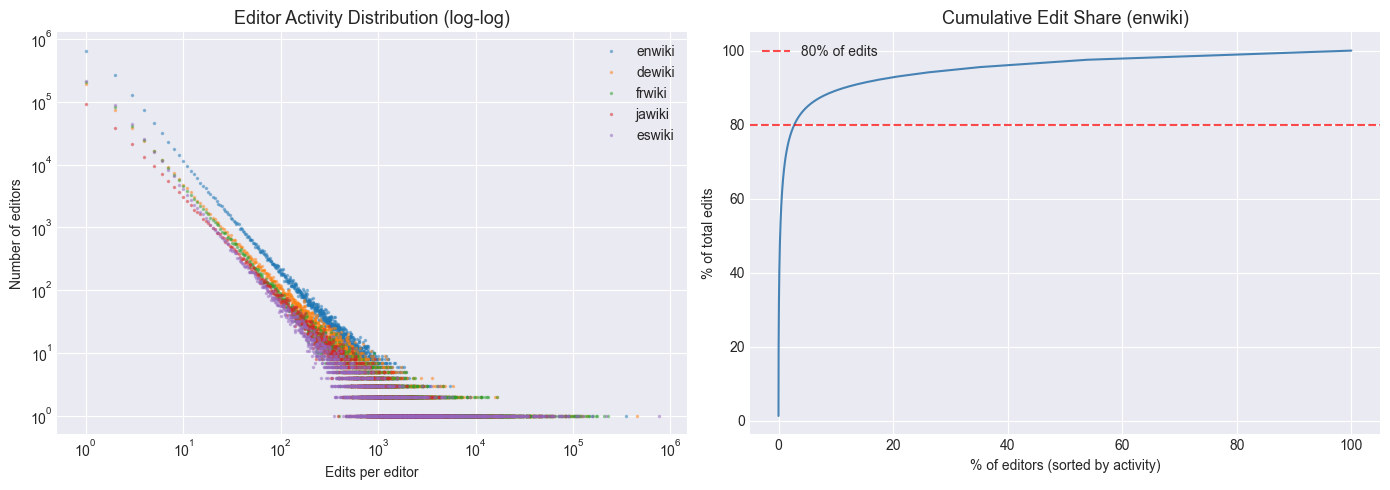

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for wiki, df in dfs.items():
    edits_per_editor = df.groupby('contributor_id').size()
    counts = edits_per_editor.value_counts().sort_index()
    axes[0].loglog(counts.index, counts.values, '.', alpha=0.4, markersize=3, label=wiki)

axes[0].set_title('Editor Activity Distribution (log-log)', fontsize=13)
axes[0].set_xlabel('Edits per editor')
axes[0].set_ylabel('Number of editors')
axes[0].legend()

# Cumulative: what % of edits come from top X% of editors
df_en = dfs.get('enwiki', list(dfs.values())[0])
edits_per_editor = df_en.groupby('contributor_id').size().sort_values(ascending=False)
cumulative = edits_per_editor.cumsum() / edits_per_editor.sum() * 100
pct_editors = np.arange(1, len(cumulative)+1) / len(cumulative) * 100
axes[1].plot(pct_editors, cumulative.values, color='steelblue')
axes[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% of edits')
axes[1].set_title('Cumulative Edit Share (enwiki)', fontsize=13)
axes[1].set_xlabel('% of editors (sorted by activity)')
axes[1].set_ylabel('% of total edits')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, '01_editor_distribution.png'), dpi=150)
plt.show()

## 4. Storage: XML Dump vs Parquet

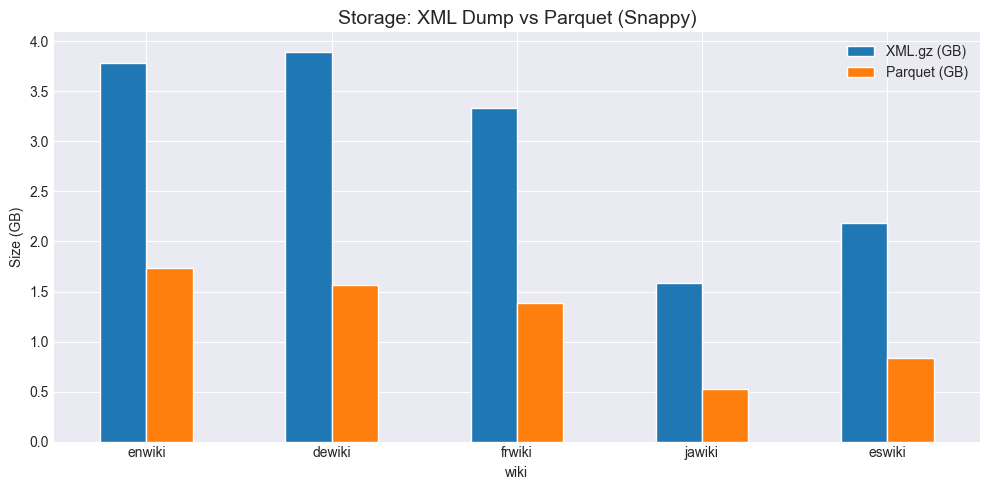

        XML.gz (GB)  Parquet (GB)  compression_ratio
wiki                                                
enwiki        3.783         1.737              2.179
dewiki        3.896         1.561              2.496
frwiki        3.333         1.385              2.406
jawiki        1.583         0.529              2.992
eswiki        2.187         0.837              2.614


In [5]:
storage = []
for wiki in wikis:
    gz_files = glob.glob(os.path.join(DUMPS, wiki, '*.xml.gz'))
    parquet_file = os.path.join(PARQUET, f'{wiki}.parquet')
    gz_size = sum(os.path.getsize(f) for f in gz_files) / 1e9
    pq_size = os.path.getsize(parquet_file) / 1e9 if os.path.exists(parquet_file) else 0
    if gz_size > 0:
        storage.append({'wiki': wiki, 'XML.gz (GB)': gz_size, 'Parquet (GB)': pq_size})

storage_df = pd.DataFrame(storage).set_index('wiki')
ax = storage_df.plot(kind='bar', figsize=(10, 5), edgecolor='white')
ax.set_title('Storage: XML Dump vs Parquet (Snappy)', fontsize=14)
ax.set_ylabel('Size (GB)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, '01_storage_comparison.png'), dpi=150)
plt.show()
storage_df['compression_ratio'] = storage_df['XML.gz (GB)'] / storage_df['Parquet (GB)']
print(storage_df.round(3))

## 5. Temporal Edit Patterns

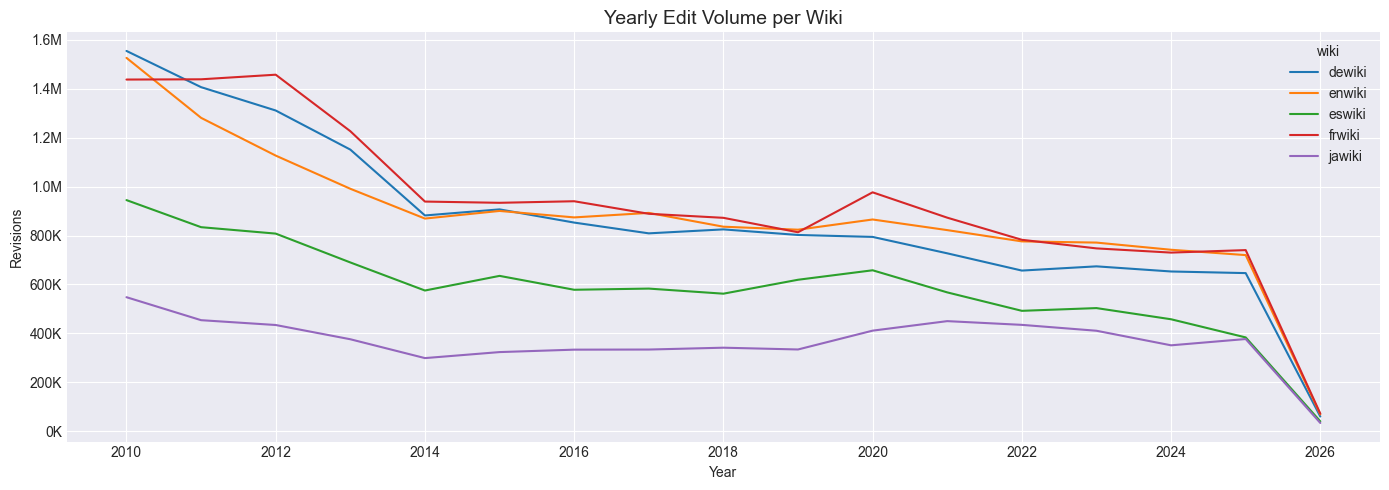

In [6]:
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'], errors='coerce')
df_all['year'] = df_all['timestamp'].dt.year

yearly = df_all.groupby(['wiki', 'year']).size().unstack(level=0).fillna(0)
yearly = yearly[yearly.index >= 2010]

ax = yearly.plot(figsize=(14, 5))
ax.set_title('Yearly Edit Volume per Wiki', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Revisions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, '01_yearly_edits.png'), dpi=150)
plt.show()

## Summary

| Metric | Value |
|--------|-------|
| Total revisions | see above |
| Largest wiki | enwiki |
| Editor distribution | Power-law (few editors make most edits) |
| Parquet vs XML.gz | Parquet is smaller due to columnar + snappy |

**Key finding:** Editor activity follows a power-law distribution — a small fraction of editors (~5%) account for ~80% of all edits. This is the classic Wikipedia editor inequality pattern.